<a href="https://colab.research.google.com/github/Muse-M/FinalYearProject/blob/main/Combine_Classifier_results_with_regressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Combining ResNet 50 classfier to ResNet 50 regressor

- taking the logits from previously trained classifier and adding them to the fully connected section in the regressor
- Aside fro logits I also tested using proababilites and labels, results are saved to drive graphs are available in meeting 4 powerpoint

## Imports

In [1]:
!pip install optuna captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.8/231.8 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
# Pytorch imports
import torch
import torch.utils.data as data
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter
import optuna
import captum
from captum.attr import (
    GradientShap,
    DeepLift,
    DeepLiftShap,
    IntegratedGradients,
    LayerConductance,
    NeuronConductance,
    NoiseTunnel)

# General Python imports
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif" # Standardise font throughout whole notebook
from   matplotlib.ticker import AutoMinorLocator
import seaborn as sns
import numpy as np
import os
import pandas as pd
import pickle
from datetime import datetime
import joblib

# Quality of life imports
from tqdm.notebook import tqdm # progress Bar
from accelerate import Accelerator

# data processing
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Import tensorboard logger from PyTorch
from torch.utils.tensorboard import SummaryWriter
# Load tensorboard extension for Jupyter Notebook, only need to start TB in the notebook
%load_ext tensorboard

In [3]:
################UoA code################
torch.manual_seed(42) # Setting the seed

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device", device)

# GPU operations have a separate seed we also want to set
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)

# Additionally, some operations on a GPU are implemented stochastic for efficiency
# We want to ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Device cuda


## Data loading

In [4]:
dataPath='/content/drive/MyDrive/Many QSO + all gal'
filePaths=[]
for i in os.listdir(dataPath):
  filePaths.append(os.path.join(dataPath, i))

In [5]:
from concurrent.futures import ThreadPoolExecutor
def load_pickle(file_path):
    a=filePaths.index(file_path)
    if a%1000==0:
        print(str(a)+'/10000')
    with open(file_path, "rb") as f:
        data = pickle.load(f)
        data['wl'] = data['wl'].flatten()
        df=pd.DataFrame(data)
        df_single_row = pd.DataFrame({col: [df[col].tolist()] for col in df.columns})
        return df_single_row

# Load files in parallel
# Loads each pickle file from drive as a dataframe with 1 row and adds to list dataframes
with ThreadPoolExecutor() as executor:
    dataframes = list(executor.map(load_pickle, filePaths))

# concatenate all dataframes into 1 dataframe
final_df = pd.concat(dataframes, ignore_index=True)
final_df.shape

0/10000
1000/10000
2000/10000
3000/10000
4000/10000
5000/10000
6000/10000
7000/10000
8000/10000
9000/10000


(10000, 6)

In [6]:
firstDataset=final_df.copy(deep=True)
# converts columns that should be single valued into single values i.e [0.01,0.01,0.01....] => 0.01
firstDataset['f_gal'] = firstDataset['f_gal'].apply(lambda x: x[0])
firstDataset['gal_type'] = firstDataset['gal_type'].apply(lambda x: x[0])

# transforms categorical gal_types into numeric
le = LabelEncoder()
firstDataset['gal_type_code'] = le.fit_transform(firstDataset['gal_type'])

In [7]:
firstDataset.head()

,wl,flux,true_AGN,true_gal,gal_type,f_gal,gal_type_code
0,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.5879516667037834, 1.5875734218403277, 1.590...","[1.5804356054420239, 1.5801577479461435, 1.583...","[0.007516061261759431, 0.007415673894184079, 0...",SF,0.01,2
1,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[0.9886330706453645, 0.9941504273455667, 0.984...","[0.7707842821379141, 0.7766115233167897, 0.772...","[0.21784878850745043, 0.21753890402877699, 0.2...",green,0.43,3
2,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.3773286006067391, 1.3804289543271433, 1.372...","[1.2607353268564312, 1.2675884312909873, 1.260...","[0.11659327375030794, 0.112840523036156, 0.112...",PSB,0.20,0
3,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.5972932084239753, 1.588366287774871, 1.5859...","[1.5382612681105197, 1.5291207538284406, 1.526...","[0.059031940313455496, 0.05924553394643046, 0....",SB,0.06,1
4,"[3300.654, 3301.4141, 3302.1744, 3302.9348, 33...","[1.0141684137895761, 1.015296388556483, 1.0097...","[0.8181937731146112, 0.8196005169294199, 0.819...","[0.19597464067496487, 0.19569587162706306, 0.1...",green,0.38,3


In [8]:
# Dataset class for classifier
class classifier_DataSet(data.Dataset):
  def __init__(self, flux, fraction, galTypeCode):
    self.data=flux
    self.label=fraction
    self.galTypeCode=galTypeCode
    self.generateData()
    self.size=len(self.data)

  def generateData(self): # a single datum contains data=spectra flux, label=f_gal, galtypecode(for potential graphing use)
    self.tensordata=torch.Tensor(self.data)
    self.tensorlabel=torch.Tensor(self.label)
    self.tensorGalTypeCode=torch.Tensor(self.galTypeCode)

  # define __getitem__, and __len__ to define pytorch dataset, allows you use dataset[index] wihout needed to do dataset.getitem(index)
  def __getitem__(self, index):
    data_point = self.tensordata[index]
    data_label = self.tensorlabel[index]
    gal_typeCode = self.tensorGalTypeCode[index]
    return data_point, data_label, gal_typeCode

  def  __len__(self):
    return self.size

#create dataset
fullDataset_forClassifier=classifier_DataSet(firstDataset['flux'], firstDataset['f_gal'], firstDataset['gal_type_code'])

In [9]:
#split data set into train, validation, test (8800,200,1000)
trainDataset, testDataset = torch.utils.data.random_split(fullDataset_forClassifier, [9000,1000])
trainDataset, validDataset = torch.utils.data.random_split(trainDataset, [8800,200])

In [10]:
# Split data into batches. Also splits data from label, useful when traning the classifier but model is already trained and being loaded in
train_data_loader = data.DataLoader(trainDataset, batch_size=40, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader = data.DataLoader(validDataset, batch_size=100, shuffle=True)
test_data_loader = data.DataLoader(testDataset, batch_size=500, shuffle=True)

## ResNet 50 classifier class

In [11]:
class singleBlock(nn.Module):
    def __init__(self, input_ch, output_ch, kernel, stride):
        super().__init__()

        pad=int((kernel-1)/2)
        self.conv=nn.Conv1d(input_ch, output_ch, kernel, stride, pad)
        self.bn=nn.BatchNorm1d(output_ch)

    def forward(self, x):
        x= self.conv(x)
        x= self.bn(x)
        return x


class residualBlock(nn.Module):
    def __init__(self, input_ch, output_ch, downsample,firstLayerInBlock, stride, bottleNeckRequired):
        super().__init__()

        if firstLayerInBlock:
            downSampleFactor=2
            self.input_ch=int(input_ch/2)
        else:
            downSampleFactor=4
            self.input_ch=input_ch


        self.output_ch=output_ch
        if bottleNeckRequired:
            self.bottleNeckChannelSize=int(self.input_ch/downSampleFactor)
        else:
            self.bottleNeckChannelSize=self.input_ch

        self.conv1=singleBlock(self.input_ch, self.bottleNeckChannelSize, 1, 1)
        self.conv2=singleBlock(self.bottleNeckChannelSize,self.bottleNeckChannelSize,3,stride)
        self.conv3=singleBlock(self.bottleNeckChannelSize, self.output_ch,1,1)
        self.act= nn.ReLU()

        self.downsample=downsample
        if self.input_ch != self.output_ch:
            self.downsample=True
        if self.downsample:
            self.downsampleConv=singleBlock(self.input_ch, self.output_ch, 1,stride)

    def forward(self, x):

        f=self.act(self.conv1(x))
        f=self.act(self.conv2(f))
        f=self.conv3(f)


        if self.downsample:
            x=self.downsampleConv(x)


        h=f+x
        return self.act(h)



class ResNet50_classifier(nn.Module):
    def __init__(self, dataChannels, blockList, channelList, finalOutputNo, bottleNeckRequired, stride,**kwargs):
        super().__init__()

        self.blockList=blockList
        self.channelList=channelList
        self.classes=finalOutputNo
        self.stride=stride

        self.firstConv=nn.Conv1d(dataChannels, self.channelList[0], 3,2,3)
        self.BN=nn.BatchNorm1d(self.channelList[0])
        self.act=nn.ReLU()
        self.maxPool=nn.MaxPool1d(3,2,1)

        if self.channelList[0] != self.channelList[1]:
            # takes output from input layer and increase number of channels to size needed to make sure it can add with the first block of middle layers
            self.middleLayerFirstPartUpsample=nn.Conv1d(self.channelList[0], self.channelList[1], 1,1,0)

        self.bottleNeckRequired=bottleNeckRequired # if high number of filters, downsample is needed at the start of layers


        self._createNetwork()
        self._initWeights()


    def _createNetwork(self):
        self.inputLayer=nn.Sequential(
            self.firstConv,
            self.BN,
            self.act,
            self.maxPool
        )



        self.middleLayersPart1=nn.Sequential(
            singleBlock(self.channelList[0], self.channelList[0], 1, 1),
            nn.ReLU(),
            singleBlock(self.channelList[0],self.channelList[0], 3, 1),
            nn.ReLU(),
            singleBlock(self.channelList[0], self.channelList[1], 1, 1),
        )

        self.blockList[1]=self.blockList[1]-1

        self.middleLayersPart2=nn.Sequential()

        for layer in range(1,len(self.blockList)):
            for i in range(self.blockList[layer]):
                #print('layer', layer, 'block', i)

                firstLayerInBlock = True if (i==0 and layer !=1 and self.channelList[layer] != self.channelList[layer-1] ) else False
                stride=self.stride[layer]
                downsample=True if stride == 2 else False # required when size of input and output dont match, which is when stride isnt 1 or inbetween different residual block, the second case is checked in the class

                self.middleLayersPart2.add_module(str(layer)+' '+str(i),
                                                  residualBlock(self.channelList[layer],
                                                                self.channelList[layer],
                                                                downsample,
                                                                firstLayerInBlock,
                                                                stride,
                                                                self.bottleNeckRequired))

        self.outputLayers=nn.Sequential(
            nn.AdaptiveAvgPool1d(1), # reduces to 1 value per channel
            nn.Flatten(),
            nn.Linear(self.channelList[-1], self.classes)
        )


    def _initWeights(self):
        for m in self.modules():
            if (isinstance(m,nn.Conv1d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu') # test different intialisations, different modes
            elif (isinstance(m, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x=self.inputLayer(x)
        identity=x
        x=self.middleLayersPart1(x) # first block of first layer in middle part

        if self.channelList[0] != self.channelList[1]:
            identity=self.middleLayerFirstPartUpsample(identity)
        x=identity+x
        x=self.act(x)

        x=self.middleLayersPart2(x)
        x=self.outputLayers(x)
        return x


## Load Classifier in and calculate logits

- create new dataset which includes logits

In [154]:
#load model in
blockList=['placeHolder',2,2,2]
channelList=[64,128,256,512]
stride=['placeHolder',1,1,2]
name='RN50-C: 0305-181112'

modelDict = torch.load('/content/drive/MyDrive/TensorBoard_Data/ResNet50Classifier/fullDataRuns/best_model/20250305-181112.pt', map_location=torch.device(device))
Model = ResNet50_classifier(1, blockList, channelList, 5, False, stride)
Model.load_state_dict(modelDict['model_state_dict'])
Model.to(device)
print('Model Name:', name , 'Val Acc:', modelDict['accuracy'])

<ipython-input-154-9262b864dc8f>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  modelDict = torch.load('/content/drive/MyDrive/TensorBoard_Data/ResNet50Classifier/fullData

Model Name: RN50-C: 0305-181112 Val Acc: tensor(94., device='cuda:0')


In [155]:
# re define train_data_loader so shuffle is false, so after predicting logits the values predicted are in the correct order
data_loader_forLogits = data.DataLoader(fullDataset_forClassifier, batch_size=40, num_workers=0, pin_memory=False ,shuffle=False)

Model.eval()
allLogits=[]
softmaxLayer=nn.Softmax()
with torch.no_grad():
    for batch_data,_,_ in data_loader_forLogits:
        logits = Model(batch_data.unsqueeze(1).to(device))
        allLogits.append(softmaxLayer(logits))


data_logits=torch.cat(allLogits, dim=0)
data_logits.shape
data_logits[0:5]

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


tensor([[3.6747e-01, 1.3792e-01, 2.1386e-01, 1.0384e-01, 1.7691e-01],
        [3.0528e-03, 9.9830e-08, 5.8297e-04, 9.8408e-01, 1.2289e-02],
        [9.0072e-01, 1.7805e-03, 5.8621e-02, 3.5098e-02, 3.7796e-03],
        [8.7870e-03, 8.6938e-01, 1.1393e-01, 4.1479e-03, 3.7588e-03],
        [6.3034e-03, 1.7062e-07, 6.0571e-04, 9.8139e-01, 1.1699e-02]],
       device='cuda:0')

In [156]:
# Dataset class for regressor
class regressor_Dataset(data.Dataset):
  def __init__(self, flux, fraction, galTypeCode, logits):
    self.data=flux
    self.label=fraction
    self.galTypeCode=galTypeCode
    self.logits=logits

    self.generateData()
    self.size=len(self.data)

  def generateData(self): # a single datum contains data=spectra flux, label=f_gal, galtypecode(for potential graphing use)
    self.tensordata=torch.Tensor(self.data)
    self.tensorlabel=torch.Tensor(self.label)
    self.tensorGalTypeCode=torch.Tensor(self.galTypeCode)
    self.tensorlogits=torch.Tensor(self.logits)

  # define __getitem__, and __len__ to define pytorch dataset, allows you use dataset[index] wihout needed to do dataset.getitem(index)
  def __getitem__(self, index):
    data_point = self.tensordata[index]
    data_label = self.tensorlabel[index]
    gal_typeCode = self.tensorGalTypeCode[index]
    data_logits = self.tensorlogits[index]
    return data_point, data_label, gal_typeCode, data_logits

  def  __len__(self):
    return self.size

#create dataset [flux: list size 1890, f_gal: float, gal_type_code: int, gal_type_logits: list size 5]
fullDataset_for_regressor=regressor_Dataset(fullDataset_forClassifier[:][0], fullDataset_forClassifier[:][1], fullDataset_forClassifier[:][2], data_logits)

In [157]:
#split data set into train, validation, test (8800,200,1000)
trainDataset, testDataset = torch.utils.data.random_split(fullDataset_for_regressor, [9000,1000])
trainDataset, validDataset = torch.utils.data.random_split(trainDataset, [8800,200])

In [158]:
# Split data into batches. Also splits data from label, useful when traning the classifier but model is already trained and being loaded in
train_data_loader = data.DataLoader(trainDataset, batch_size=40, num_workers=0, pin_memory=False ,shuffle=True)
valid_data_loader = data.DataLoader(validDataset, batch_size=100, shuffle=True)
test_data_loader = data.DataLoader(testDataset, batch_size=500, shuffle=True)

In [159]:
for i, j,k,l in train_data_loader:
    print(i[0],j[0],k[0],l[0])
    break

tensor([0.7309, 0.7236, 0.7153,  ..., 0.9978, 0.9811, 0.9639]) tensor(0.8900) tensor(2.) tensor([9.3756e-04, 2.8932e-04, 9.9847e-01, 2.9217e-04, 6.3396e-06],
       device='cuda:0')


## ResNet 50 Regressor class

### class

In [160]:
class singleBlock(nn.Module):
    def __init__(self, input_ch, output_ch, kernel, stride):
        super().__init__()

        pad=int((kernel-1)/2)
        self.conv=nn.Conv1d(input_ch, output_ch, kernel, stride, pad)
        self.bn=nn.BatchNorm1d(output_ch)

    def forward(self, x):
        x= self.conv(x)
        x= self.bn(x)
        return x


class residualBlock(nn.Module):
    def __init__(self, input_ch, output_ch, downsample,firstLayerInBlock, stride, bottleNeckRequired):
        super().__init__()

        if firstLayerInBlock:
            downSampleFactor=2
            self.input_ch=int(input_ch/2)
        else:
            downSampleFactor=4
            self.input_ch=input_ch


        self.output_ch=output_ch
        if bottleNeckRequired:
            self.bottleNeckChannelSize=int(self.input_ch/downSampleFactor)
        else:
            self.bottleNeckChannelSize=self.input_ch

        self.conv1=singleBlock(self.input_ch, self.bottleNeckChannelSize, 1, 1)
        self.conv2=singleBlock(self.bottleNeckChannelSize,self.bottleNeckChannelSize,3,stride)
        self.conv3=singleBlock(self.bottleNeckChannelSize, self.output_ch,1,1)
        self.act= nn.ReLU()

        self.downsample=downsample
        if self.input_ch != self.output_ch:
            self.downsample=True
        if self.downsample:
            self.downsampleConv=singleBlock(self.input_ch, self.output_ch, 1,stride)

    def forward(self, x):

        f=self.act(self.conv1(x))
        f=self.act(self.conv2(f))
        f=self.conv3(f)


        if self.downsample:
            x=self.downsampleConv(x)


        h=f+x
        return self.act(h)



class ResNet50_regressor(nn.Module):
    def __init__(self, dataChannels, blockList, channelList, finalOutputNo, bottleNeckRequired, stride,**kwargs):
        super().__init__()

        self.blockList=blockList
        self.channelList=channelList
        self.classes=finalOutputNo
        self.stride=stride

        self.firstConv=nn.Conv1d(dataChannels, self.channelList[0], 3,2,3)
        self.BN=nn.BatchNorm1d(self.channelList[0])
        self.act=nn.ReLU()
        self.maxPool=nn.MaxPool1d(3,2,1)

        if self.channelList[0] != self.channelList[1]:
            # takes output from input layer and increase number of channels to size needed to make sure it can add with the first block of middle layers
            self.middleLayerFirstPartUpsample=nn.Conv1d(self.channelList[0], self.channelList[1], 1,1,0)

        self.bottleNeckRequired=bottleNeckRequired # if high number of filters, downsample is needed at the start of layers


        self._createNetwork()
        self._initWeights()


    def _createNetwork(self):
        self.inputLayer=nn.Sequential(
            self.firstConv,
            self.BN,
            self.act,
            self.maxPool
        )



        self.middleLayersPart1=nn.Sequential(
            singleBlock(self.channelList[0], self.channelList[0], 1, 1),
            nn.ReLU(),
            singleBlock(self.channelList[0],self.channelList[0], 3, 1),
            nn.ReLU(),
            singleBlock(self.channelList[0], self.channelList[1], 1, 1),
        )

        self.blockList[1]=self.blockList[1]-1

        self.middleLayersPart2=nn.Sequential()

        for layer in range(1,len(self.blockList)):
            for i in range(self.blockList[layer]):
                #print('layer', layer, 'block', i)

                firstLayerInBlock = True if (i==0 and layer !=1 and self.channelList[layer] != self.channelList[layer-1] ) else False
                stride=self.stride[layer]
                downsample=True if stride == 2 else False # required when size of input and output dont match, which is when stride isnt 1 or inbetween different residual block, the second case is checked in the class

                self.middleLayersPart2.add_module(str(layer)+' '+str(i),
                                                  residualBlock(self.channelList[layer],
                                                                self.channelList[layer],
                                                                downsample,
                                                                firstLayerInBlock,
                                                                stride,
                                                                self.bottleNeckRequired))

        # self.outputLayers=nn.Sequential(
        #     nn.AdaptiveAvgPool1d(1), # reduces to 1 value per channel
        #     nn.Flatten(),
        #     nn.Linear(self.channelList[-1], self.classes)
        # )

        self.outputLayerAvgPool=nn.AdaptiveAvgPool1d(1)
        self.outputflattenLayer=nn.Flatten()
        self.outputFC=nn.Linear(self.channelList[-1]+5, self.classes) # plus 5 for the nodes added from classification resnet


    def _initWeights(self):
        for m in self.modules():
            if (isinstance(m,nn.Conv1d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu') # test different intialisations, different modes
            elif (isinstance(m, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x, galType_logits):
        x=self.inputLayer(x)
        identity=x
        x=self.middleLayersPart1(x) # first block of first layer in middle part

        if self.channelList[0] != self.channelList[1]:
            identity=self.middleLayerFirstPartUpsample(identity)
        x=identity+x
        x=self.act(x)

        x=self.middleLayersPart2(x)
        x=self.outputLayerAvgPool(x) # 1 value per channel
        x=self.outputflattenLayer(x) # flatten to 1 dim
        x=torch.cat((x,galType_logits), dim=1) # concat the 5 logit from classifier
        x=self.outputFC(x) # fully connected layer to output 1 node
        return x


### Training and Graphing functions

#### Training

In [161]:
def trainResNet_Regressor(model, traindataLoader, validdataLoader, optimiser, lossCalculator, epochs, scheduler,logging_dir, modelIndex,verbose, tuningReport=None):

    # location for tensorboard graphing data
    writer=SummaryWriter(logging_dir+'/runs/results/'+modelIndex)
    initBoard=False

    # Save the best model with lowest validation loss
    current_best_model={'epoch':-1, 'model_params':model.state_dict(), 'lossScore':np.inf}

    #train on traning set epochs times
    for epoch in tqdm(range(epochs)):
        epoch_train_loss=0
        epoch_valid_loss=0
        model.train()
        for batch_data, batch_label, _ , batch_logits in traindataLoader:
            batch_data=batch_data.unsqueeze(1)
            batch_data=batch_data.to(device) # brings data to cpu or gpu
            batch_label=batch_label.to(device)
            batch_logits=batch_logits.to(device)

            # intialises tensorboard graph during first loop
            if not initBoard:
                writer.add_graph(model, (batch_data, batch_logits)) # needs to be on gpu before calling this
                initBoard = True

            prediction=model(batch_data, batch_logits).squeeze()
            loss= lossCalculator(prediction, batch_label)
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

            epoch_train_loss += loss.item() # per batch

        # Add average loss to TensorBoard
        epoch_train_loss /= len(traindataLoader) #average over number of batches
        epoch_valid_loss+=validate_model(model, validdataLoader, lossCalculator) # (already averaged)

        scheduler.step(epoch_valid_loss) # if validation score hasn't decreased in a while, reduce learning rate by factor of 10

        if verbose==True: # Check if loss should be ouput after epochs
            if epochs > 19: # if number of total epochs is too large
                if epoch%10 == 0: # print every 10
                    print('Epoch No:',epoch+1,'Train loss: ', epoch_train_loss, 'Valid loss:', epoch_valid_loss, 'lr', scheduler.get_last_lr()[0])
            else: # print after each epoch
                print('Epoch No:',epoch+1,'Train loss: ', epoch_train_loss, 'Valid loss:', epoch_valid_loss, 'lr', scheduler.get_last_lr()[0])

        writer.add_scalars('Losses', {'traning_loss': epoch_train_loss,
                                    'validation_loss': epoch_valid_loss},
                        global_step = epoch + 1) # adds traning and validation loss to tensorboard grpah

        # add previous learning rate (before it potentially got reduced) to tensorboard
        writer.add_scalar('Learning rate',scheduler.get_last_lr()[0], global_step=epoch+1)

        # If current epoch model is better than current best model, overwrite best model (validation score)
        if current_best_model['lossScore'] > epoch_valid_loss:
            current_best_model['epoch']= epoch+1
            current_best_model['model_params']=model.state_dict()
            current_best_model['lossScore']=epoch_valid_loss

        # Add average loss to optune
        if tuningReport != None:
            tuningReport.report(epoch_valid_loss, epoch)
            if tuningReport.should_prune():
                raise optuna.exceptions.TrialPruned()

    writer.close()
    print('Epoch No:',epoch+1,'Train loss: ', epoch_train_loss, 'Valid loss:', epoch_valid_loss, 'lr', scheduler.get_last_lr()[0])

    #after training is complete, save the best epoch model to drive to be able to load it later
    print('Best Epoch:',current_best_model['epoch'])

    if tuningReport == None: # only save when not performing grid search, space saving reasons
        torch.save(current_best_model['model_params'], logging_dir+'/best_model/'+modelIndex+'.pt')

    return [epoch_train_loss, epoch_valid_loss]


def validate_model(model, validdataLoader, lossCalculator):
    model.eval() # set into eval mode to not update gradients when using validation data
    with torch.no_grad():
        lossValue=0
        for batch_data, batch_label, _ , batch_logits in validdataLoader:
            batch_data=batch_data.unsqueeze(1)
            batch_data=batch_data.to(device)
            batch_label=batch_label.to(device)
            batch_logits=batch_logits.to(device)

            prediction=model(batch_data, batch_logits).squeeze()
            lossValue+=lossCalculator(prediction, batch_label)

        lossValue /= len(validdataLoader)
    return lossValue

#### Graphing

In [162]:
#graph
def dataFor_graphPredictionTruth(model, train_data_loader_loc, valid_data_loader_loc ):
    # returns model predictions on training and validation data
    model.eval()
    predict_train=np.array([])
    truth_train=np.array([])
    diff_train=np.array([])
    hue_train=np.array([])


    for trial_batch in train_data_loader_loc:
        with torch.no_grad():
            trial_batch_p=trial_batch[:][0].to(device)
            trial_batch_t=trial_batch[:][1].to(device)
            trial_batch_hue=trial_batch[:][2]
            trial_batch_logits=trial_batch[:][3].to(device)

            predict_train=np.append(predict_train, model(trial_batch_p.unsqueeze(1), trial_batch_logits).cpu().squeeze().detach().numpy())
        truth_train=np.append(truth_train, trial_batch_t.cpu().detach().numpy())
        hue_train=np.append(hue_train, trial_batch_hue.cpu().detach().numpy())

    diff_train=np.append(diff_train,truth_train-predict_train)


    predict_val=np.array([])
    truth_val=np.array([])
    diff_val=np.array([])
    hue_val=np.array([])
    for valid_batch in valid_data_loader_loc:
        with torch.no_grad():
            trial_batch_p=valid_batch[:][0].to(device)
            trial_batch_t=valid_batch[:][1].to(device)
            trial_batch_logits=valid_batch[:][3].to(device)

            predict_val=np.append(predict_val, model(trial_batch_p.unsqueeze(1),trial_batch_logits ).cpu().squeeze().detach().numpy())
        truth_val=np.append(truth_val,trial_batch_t.cpu().detach().numpy())
        hue_val=np.append(hue_val,valid_batch[:][2].cpu().detach().numpy())

    diff_val=truth_val-predict_val

    return [predict_train,truth_train,diff_train, hue_train], [predict_val,truth_val,diff_val,hue_val]

In [163]:
def graphPredictionTruth(predict_train, truth_train, diff_train, hue_train,predict_val, truth_val, diff_val, hue_val, attempt,ax, hueBool, le):
    # uses prediction from dataFor_graphPredictionTruth_alex to plot graphs
    ax[0].set_yticklabels([])
    ax[0].set_xticklabels([])
    ax[1].set_yticklabels([])
    ax[1].set_xticklabels([])

    frame2=fig.add_axes((.05,.25,.45,.75)) # splits graphs into 4 graphs with bottom 2 graphs being smaller
    frame1=fig.add_axes((.05,.01,.45,.25))

    frame4=fig.add_axes((.54,.25,.45,.75))
    frame3=fig.add_axes((.54,.01,.45,.25))


    # creates 2D array of training results and validation results
    t = np.array(list(zip(predict_train, truth_train, diff_train, hue_train)), dtype = [('predict', float), ('truth', float), ('diff', float), ('gal_type', int)])
    if hueBool == False:
        # doesn't colour based on gal_type
        frame2.scatter(x=t['truth'], y=t['predict'], c='blue', alpha=0.2, label='Data')
        frame1.scatter(x=t['truth'], y=t['diff'], c='blue', alpha=0.2)
    else:
        # colours based on gal type
        df = pd.DataFrame.from_records(t)
        df['gal_type']=le.inverse_transform(df['gal_type'])
        sns.scatterplot(data=df, x='truth', y='predict', hue='gal_type', ax=frame2, alpha=0.2, hue_order=['SB', 'SF', 'green','red', 'PSB'])
        sns.scatterplot(data=df, x='truth', y='diff',hue='gal_type', ax=frame1, alpha=0.2,hue_order=['SB', 'SF', 'green','red', 'PSB'])

    frame2.plot([0,1],[0,1], c='orange',label='Truth=Prediction')
    frame1.plot([0,1],[0,0], c='orange')
    #frame1.set_ylim(-0.099,0.099)

    frame1.set_xlabel('True f-gal', size=20)
    frame2.set_ylabel('Predicted f_gal', size=20)
    frame1.set_ylabel('Difference', size=16)
    frame2.set_title(attempt+' Train Set', fontsize=34)

    t = np.array(list(zip(predict_val, truth_val, diff_val, hue_val)), dtype = [('predict', float), ('truth', float), ('diff', float), ('gal_type', int)])

    if hueBool==False:
        frame4.scatter(x=t['truth'], y=t['predict'], label='Data')
        frame3.scatter(x=t['truth'], y=t['diff'], c='blue' )

    else:
        df = pd.DataFrame.from_records(t)
        df['gal_type']=le.inverse_transform(df['gal_type'])
        sns.scatterplot(data=df, x='truth', y='predict', hue='gal_type', ax=frame4,hue_order=['SB', 'SF', 'green','red', 'PSB'])
        sns.scatterplot(data=df,x='truth', y='diff', hue='gal_type', ax=frame3,hue_order=['SB', 'SF', 'green','red', 'PSB'])

    frame4.plot([0,1],[0,1], c='orange', label='Truth=Prediction')
    frame3.plot([0,1], [0,0], c='orange')
    #frame3.set_ylim(-0.099,0.099)

    frame3.set_xlabel('True f-gal', size=20)
    frame4.set_title(attempt+' Validation Set', fontsize=34)

#----------------------Labels and axis-----------------------------------------
    frame3.tick_params(axis='both', which='major', labelsize=14)
    frame3.tick_params(axis='both', which='minor', labelsize=12)
    frame4.tick_params(axis='both', which='major', labelsize=14)
    frame4.tick_params(axis='both', which='minor', labelsize=12)
    frame2.tick_params(axis='both', which='major', labelsize=14)
    frame2.tick_params(axis='both', which='minor', labelsize=12)
    frame1.tick_params(axis='both', which='major', labelsize=14)
    frame1.tick_params(axis='both', which='minor', labelsize=12)

    frame1.xaxis.set_minor_locator(AutoMinorLocator(4))
    frame1.yaxis.set_minor_locator(AutoMinorLocator(5))
    frame2.yaxis.set_minor_locator(AutoMinorLocator(4))
    frame3.xaxis.set_minor_locator(AutoMinorLocator(4))
    frame3.yaxis.set_minor_locator(AutoMinorLocator(5))
    frame4.yaxis.set_minor_locator(AutoMinorLocator(4))

    frame3.tick_params(axis='both', which='minor', labelsize=12, length=3, width=1,
                   direction='in', top=False,right=False, bottom=True)
    frame4.tick_params(axis='both', which='minor', labelsize=12, length=3, width=1,
                   direction='in', top=False,right=False, bottom=True)
    frame2.tick_params(axis='both', which='minor', labelsize=12, length=3, width=1,
                   direction='in', top=False,right=False, bottom=True)
    frame1.tick_params(axis='both', which='minor', labelsize=12, length=3, width=1,
                   direction='in', top=False,right=False, bottom=True)
    _=frame4.legend(prop={'size':13})
    _=frame2.legend(prop={'size':13})

    if hueBool:
        frame1.get_legend().set_visible(False)
        frame3.get_legend().set_visible(False)
    frame3.set_ylabel('')
    frame4.set_ylabel('')

In [164]:
def graphGalTypeHist(diff, galType, ax,le):
    t = np.array(list(zip(diff, galType)), dtype = [('diff', float), ('gal_type', int)])
    df = pd.DataFrame.from_records(t)
    df['gal_type']=le.inverse_transform(df['gal_type'])

    plot=sns.kdeplot(data=df, x='diff', hue='gal_type', ax=ax, fill=False,
                hue_order=['SB', 'SF', 'green','red', 'PSB'], legend=True)


    #----Labels-------------------
    XaxisLimit= 0.1 #@param {type:"slider", min:0, max:0.15, step:0.01}
    axisLabelSize=20 #@param {type:"slider", min:10, max:25, step:1}
    ticklabelSize=14 #@param {type:"slider", min:10, max:25, step:1}
    legendTitleFontSize=14 #@param {type:"slider", min:10, max:25, step:1}
    legendSize=13 #@param {type:"slider", min:10, max:25, step:1}

    ax.set_xlim(-1*XaxisLimit, XaxisLimit)
    ax.set_ylabel('Density', size=axisLabelSize)
    ax.set_xlabel('Difference', size=axisLabelSize)
    ax.tick_params(axis='both', which='major', labelsize=ticklabelSize)
    sns.move_legend(plot, title='Galaxy Types', loc='upper right', title_fontsize=legendTitleFontSize,prop={'size':legendSize})


### Define resNet 50 Regressor Model V2 - uses classifcation logits data

In [170]:
# need to define, model, loss module and optimizer
blockList=['placeHolder',1,1,1] # blocks in middle layer
channelList=[10,10,20,40] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,1]

model=ResNet50_regressor(1, blockList, channelList,1, False, stride)

loss= nn.MSELoss()
optimiser= torch.optim.SGD(model.parameters(), lr=0.001, weight_decay=0.0001,momentum=0.9)
lrScheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min')


# train
log_dir= 'drive/MyDrive/TensorBoard_Data/ResNet50V2-Regressor/fullDataRuns'
modelIndex= datetime.now().strftime("%Y%m%d-%H%M%S")
model.to(device)
trainResNet_Regressor(model, train_data_loader, valid_data_loader,optimiser, loss, 50, lrScheduler, log_dir,modelIndex,True, None)

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch No: 1 Train loss:  0.032998715275475245 Valid loss: tensor(0.0116, device='cuda:0') lr 0.001
Epoch No: 11 Train loss:  0.004772216440919279 Valid loss: tensor(0.0017, device='cuda:0') lr 0.001
Epoch No: 21 Train loss:  0.00327921661849938 Valid loss: tensor(0.0050, device='cuda:0') lr 0.001
Epoch No: 31 Train loss:  0.003035646304223602 Valid loss: tensor(0.0020, device='cuda:0') lr 0.0001
Epoch No: 41 Train loss:  0.0026923208378403533 Valid loss: tensor(0.0016, device='cuda:0') lr 0.0001
Epoch No: 50 Train loss:  0.002657440774518446 Valid loss: tensor(0.0013, device='cuda:0') lr 1e-05
Best Epoch: 46


[0.002657440774518446, tensor(0.0013, device='cuda:0')]

In [171]:
#graph data
blockList=['placeHolder',1,1,1] # blocks in middle layer
channelList=[10,10,20,40] # 1= input layer channels, 2,3,4= middle layer channels
stride=['placeHolder',1,1,1]

name='RN50V2- 0309-201106'

modelDict = torch.load('/content/drive/MyDrive/TensorBoard_Data/ResNet50V2-Regressor/fullDataRuns/best_model/20250309-201106.pt', map_location=torch.device(device))
Model = ResNet50_regressor(1, blockList, channelList,1, False, stride)
Model.load_state_dict(modelDict)
Model.to(device)

trainGraphData_initial, valGraphData_initial=dataFor_graphPredictionTruth(Model, train_data_loader, valid_data_loader)

<ipython-input-171-b891ce1b1a98>:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  modelDict = torch.load('/content/drive/MyDrive/TensorBoard_Data/ResNet50V2-Regressor/fullDa

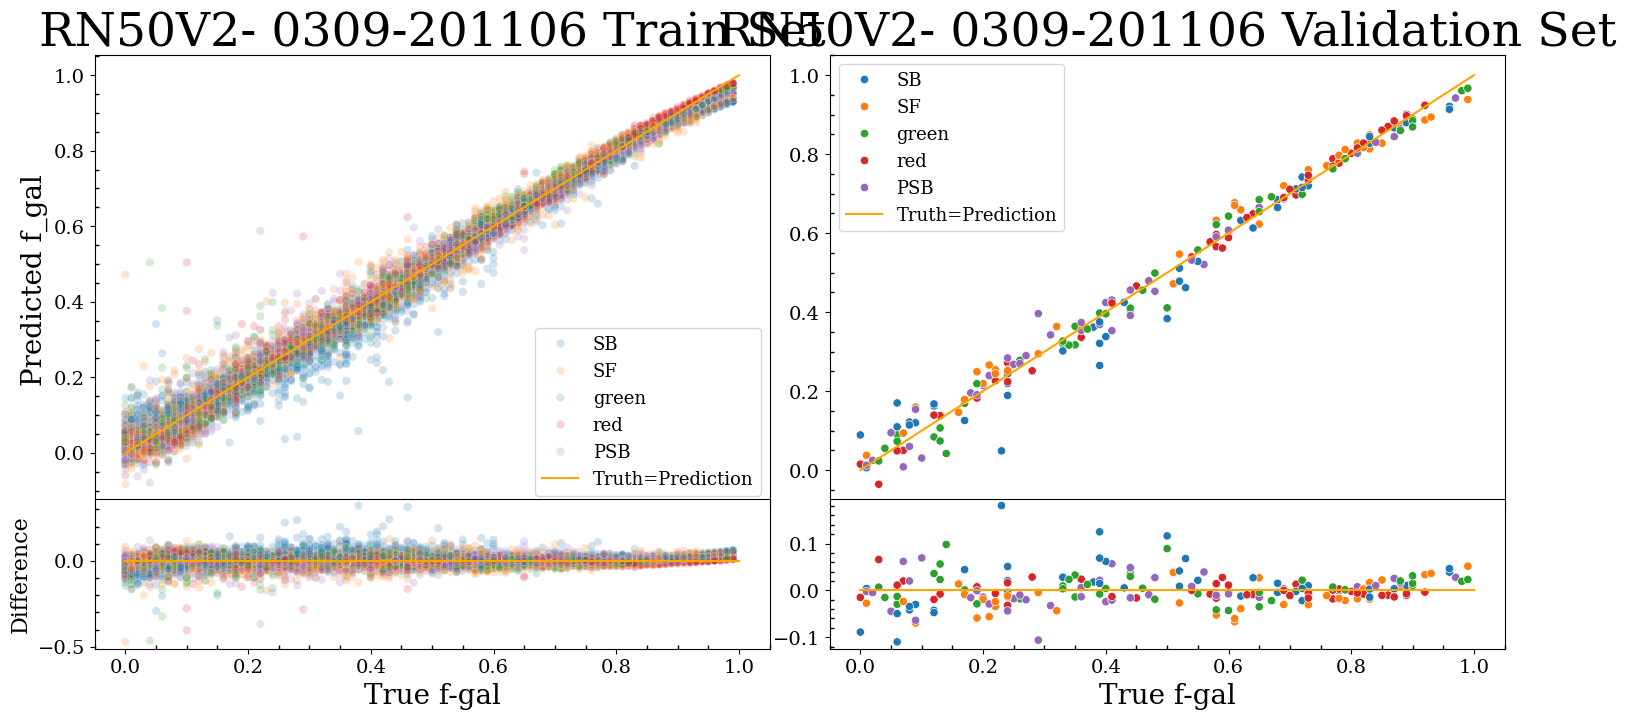

In [172]:
#graph the results
%matplotlib inline
fig, ax=plt.subplots(figsize=(15,6), ncols=2)
graphPredictionTruth(*trainGraphData_initial,*valGraphData_initial,name, ax, True,le)

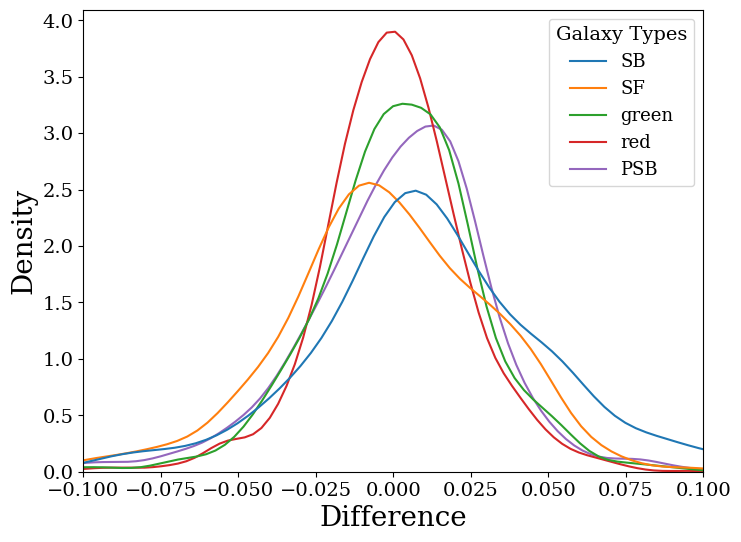

In [173]:
fig, ax = plt.subplots(figsize=(8,6))
graphGalTypeHist(trainGraphData_initial[2], trainGraphData_initial[3], ax,le)

## AlexNet regressor

### Class

In [75]:

# without gal type logits
class AlexNet_noLogits(nn.Module):
    def __init__(self,hiddenlayerCh,fcLayerCh, kernel, stride ):
        super().__init__()

        self.conv1=convBlock(1        ,        hiddenlayerCh[0],  kernel[0], stride[0], True, True, 3, 2)
        self.conv2=convBlock(hiddenlayerCh[0], hiddenlayerCh[1],  kernel[1], stride[1], True, True, 3, 2)
        self.conv3=convBlock(hiddenlayerCh[1], hiddenlayerCh[2],  kernel[2], stride[2], False, False, None, None)
        self.conv4=convBlock(hiddenlayerCh[2], hiddenlayerCh[3],  kernel[3], stride[3], False, False, None, None)
        self.conv5=convBlock(hiddenlayerCh[3], hiddenlayerCh[4],  kernel[4], stride[4], False, True, 3, 2)
        self.flatten=nn.Flatten()

        temp=outputLenCalc(1890,kernel[0], stride[0])
        temp=outputLenCalc(temp,3,2)
        temp=outputLenCalc(temp,kernel[1], stride[1])
        temp=outputLenCalc(temp,3,2)
        temp=outputLenCalc(temp,kernel[2], stride[2])
        temp=outputLenCalc(temp,kernel[3], stride[3])
        temp=outputLenCalc(temp,kernel[4], stride[4])
        flatteningFactor=outputLenCalc(temp,3,2)


#        self.fc1=fullyConnectedBlock(flatteningFactor*hiddenlayerCh[-1]+5,fcLayerCh,True,0.5,True)
        self.fc1=fullyConnectedBlock(flatteningFactor*hiddenlayerCh[-1],fcLayerCh,True,0.5,True)
        self.fc2=fullyConnectedBlock(fcLayerCh,fcLayerCh,True,0.5,True)
        self.fc3=fullyConnectedBlock(fcLayerCh,1,False,None,False)

        self._initWeights()

    def _initWeights(self):
    # paper sets conv2d weights using gaussian distribution (0, 0.01).
    #  changing that to He initialisation
    # paper sets all bias to 0 except convolution 2,4,5 and fc layers- set to 1 (keeping this)
        for m in self.modules():
            if (isinstance(m,nn.Conv1d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu') # test different intialisations, different modes
                nn.init.constant_(m.bias,0)
            elif (isinstance(m, nn.Linear)):
                nn.init.constant_(m.bias, 1)
            if m in [self.conv2.conv,self.conv4.conv,self.conv5.conv]:
                nn.init.constant_(m.bias, 1)


    def forward(self, x, galTypeLogit):
        x=self.conv1(x)
        x=self.conv2(x)
        x=self.conv3(x)
        x=self.conv4(x)
        x=self.conv5(x)

        x=self.flatten(x)


        #x=torch.cat((x,galTypeLogit), dim=1)



        x=self.fc1(x)

        x=self.fc2(x)
        x=self.fc3(x)
        return x

In [127]:
def outputLenCalc(n_in, k,s):
    pad=int((k-1)/2)
    n_out=int((n_in+2*pad-k)/s)+1
    return n_out

class convBlock(nn.Module):
    def __init__(self, input_ch, output_ch ,kernel, stride, LNBool, maxPoolBool, mpKernel, mpStride):
        super().__init__()

        # creates a generalisable single convolutional block.
        # block contains convoloutional layer, relu layer, LocalResponserNormlisation (optional), maxPool (optional)
        pad=int((kernel-1)/2)
        mpPad=int((mpKernel-1)/2) if mpKernel != None else None
        self.conv=nn.Conv1d(input_ch, output_ch, kernel, stride, pad)
        self.act=nn.ReLU()
        self.LN=nn.LocalResponseNorm(size=5, k=2) if LNBool else None # params taken from AlexNet paper (Krizhevsky et al)
        self.maxPool=nn.MaxPool1d(mpKernel, mpStride, mpPad) if maxPoolBool else None

    def forward(self,x):
        x=self.conv(x)
        x=self.act(x)
        x=self.LN(x) if self.LN != None else x
        x=self.maxPool(x) if self.maxPool != None else x
        return x

class fullyConnectedBlock(nn.Module):
    def __init__(self, input_ch, output_ch, dropoutBool, dropoutFrac, activationBool):
        super().__init__()
        # generalisable fully connected layer
        # contains fully conected layer, relu layer (optional as we dont't want final layer to have relu), dropout (optional)
        self.lin=nn.Linear(input_ch, output_ch)
        self.dropout=nn.Dropout(dropoutFrac) if dropoutBool else None
        self.act=nn.ReLU() if activationBool else None

    def forward(self,x):
        x=self.lin(x)
        x=self.dropout(x) if self.dropout != None else x
        x=self.act(x) if self.act != None else x
        return x

class AlexNet(nn.Module):
    def __init__(self,hiddenlayerCh,fcLayerCh, kernel, stride ):
        super().__init__()

        self.conv1=convBlock(1        ,        hiddenlayerCh[0],  kernel[0], stride[0], True, True, 3, 2)
        self.conv2=convBlock(hiddenlayerCh[0], hiddenlayerCh[1],  kernel[1], stride[1], True, True, 3, 2)
        self.conv3=convBlock(hiddenlayerCh[1], hiddenlayerCh[2],  kernel[2], stride[2], False, False, None, None)
        self.conv4=convBlock(hiddenlayerCh[2], hiddenlayerCh[3],  kernel[3], stride[3], False, False, None, None)
        self.conv5=convBlock(hiddenlayerCh[3], hiddenlayerCh[4],  kernel[4], stride[4], False, True, 3, 2)
        self.flatten=nn.Flatten()

        temp=outputLenCalc(1890,kernel[0], stride[0])
        temp=outputLenCalc(temp,3,2)
        temp=outputLenCalc(temp,kernel[1], stride[1])
        temp=outputLenCalc(temp,3,2)
        temp=outputLenCalc(temp,kernel[2], stride[2])
        temp=outputLenCalc(temp,kernel[3], stride[3])
        temp=outputLenCalc(temp,kernel[4], stride[4])
        flatteningFactor=outputLenCalc(temp,3,2)


        self.fc1=fullyConnectedBlock(flatteningFactor*hiddenlayerCh[-1]+1,fcLayerCh,True,0.5,True)
        self.fc2=fullyConnectedBlock(fcLayerCh,fcLayerCh,True,0.5,True)
        self.fc3=fullyConnectedBlock(fcLayerCh,1,False,None,False)

        self._initWeights()

    def _initWeights(self):
    # paper sets conv2d weights using gaussian distribution (0, 0.01).
    #  changing that to He initialisation
    # paper sets all bias to 0 except convolution 2,4,5 and fc layers- set to 1 (keeping this)
        for m in self.modules():
            if (isinstance(m,nn.Conv1d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu') # test different intialisations, different modes
                nn.init.constant_(m.bias,0)
            elif (isinstance(m, nn.Linear)):
                nn.init.constant_(m.bias, 1)
            if m in [self.conv2.conv,self.conv4.conv,self.conv5.conv]:
                nn.init.constant_(m.bias, 1)


    def forward(self,x, galTypeLogit):
        x=self.conv1(x)
        x=self.conv2(x)
        x=self.conv3(x)
        x=self.conv4(x)
        x=self.conv5(x)

        x=self.flatten(x)


        x=torch.cat((x,galTypeLogit), dim=1)



        x=self.fc1(x)

        x=self.fc2(x)
        x=self.fc3(x)
        return x

### define Model

In [131]:
hiddenlayerCh=[30,43,25,77,39]
fcLayerCh=1004
kernal=[99,9,11,5,3]
stride=[1,1,1,2,3]
alexNetModel=AlexNet( hiddenlayerCh,fcLayerCh, kernal, stride)

loss= nn.MSELoss()
optimiser=torch.optim.Adam(alexNetModel.parameters(), lr=0.001, betas=(0.9, 0.999), weight_decay=0.0005)
lrScheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min')

# train
log_dir= 'drive/MyDrive/TensorBoard_Data/AlexNet-withLogits/fullDataRuns'
modelIndex=datetime.now().strftime("%Y%m%d-%H%M%S")
alexNetModel.to(device)
trainResNet_Regressor(alexNetModel, train_data_loader, valid_data_loader,optimiser, loss, 40, lrScheduler, log_dir,modelIndex,True, None)


  0%|          | 0/40 [00:00<?, ?it/s]

Epoch No: 1 Train loss:  2.5272931901484053 Valid loss: tensor(0.0102, device='cuda:0') lr 0.001
Epoch No: 11 Train loss:  0.006884392484260554 Valid loss: tensor(0.0025, device='cuda:0') lr 0.001
Epoch No: 21 Train loss:  0.004694082128646021 Valid loss: tensor(0.0034, device='cuda:0') lr 0.001
Epoch No: 31 Train loss:  0.0033194924387234177 Valid loss: tensor(0.0019, device='cuda:0') lr 0.001
Epoch No: 40 Train loss:  0.002661411177409305 Valid loss: tensor(0.0007, device='cuda:0') lr 0.001
Best Epoch: 40


[0.002661411177409305, tensor(0.0007, device='cuda:0')]

In [132]:
#graph data
hiddenlayerCh=[30,43,25,77,39]
fcLayerCh=1004
kernal=[99,9,11,5,3]
stride=[1,1,1,2,3]


name='ANV2-0309-195143'

modelDict = torch.load('/content/drive/MyDrive/TensorBoard_Data/AlexNet-withLogits/fullDataRuns/best_model/20250309-195143.pt', map_location=torch.device(device))
AN_Model=AlexNet( hiddenlayerCh,fcLayerCh, kernal, stride)
AN_Model.load_state_dict(modelDict)
AN_Model.to(device)

trainGraphData_initial, valGraphData_initial=dataFor_graphPredictionTruth(AN_Model, train_data_loader, valid_data_loader)

<ipython-input-132-e8b5d8260cd9>:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  modelDict = torch.load('/content/drive/MyDrive/TensorBoard_Data/AlexNet-withLogits/fullDat

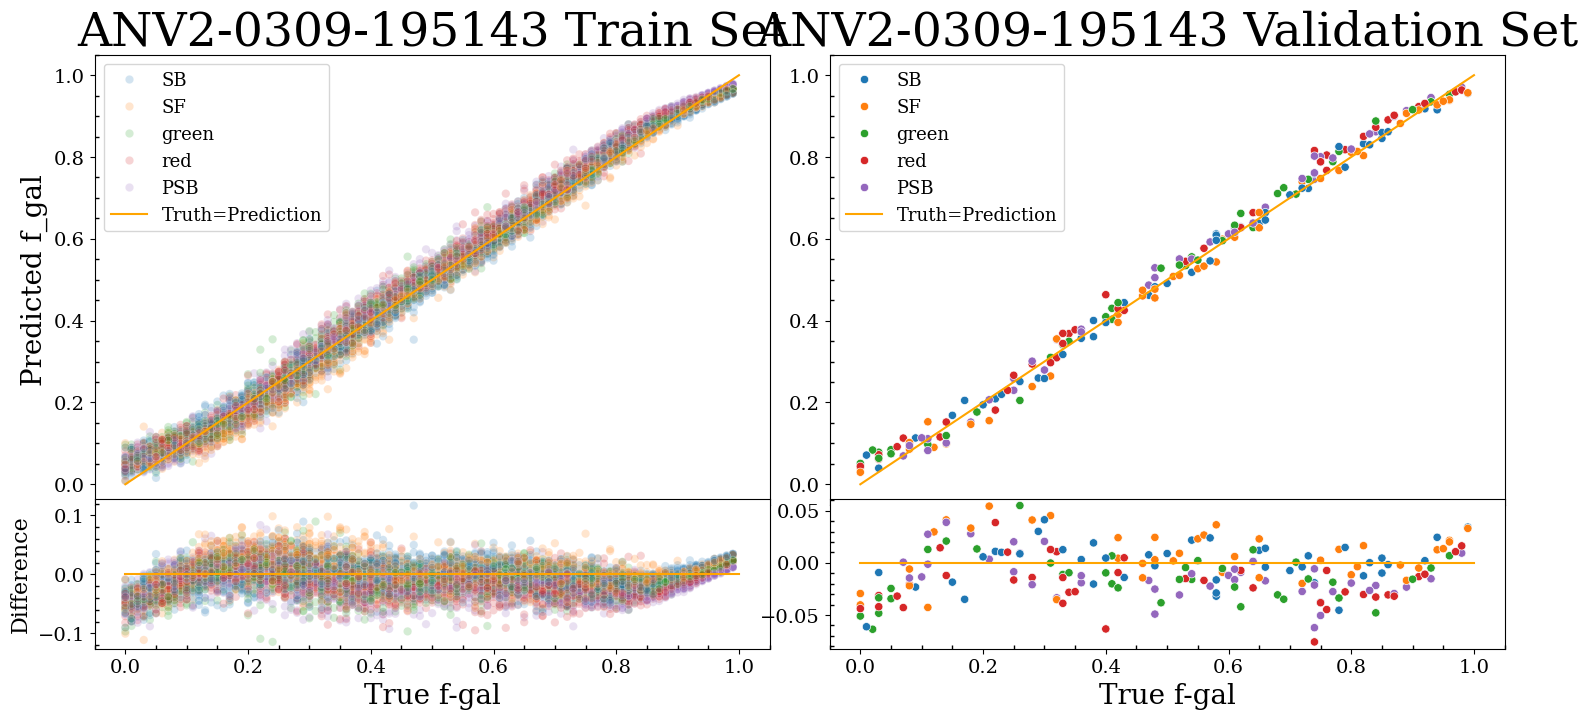

In [133]:
#graph the results
%matplotlib inline
fig, ax=plt.subplots(figsize=(15,6), ncols=2)
graphPredictionTruth(*trainGraphData_initial,*valGraphData_initial,name, ax, True,le)

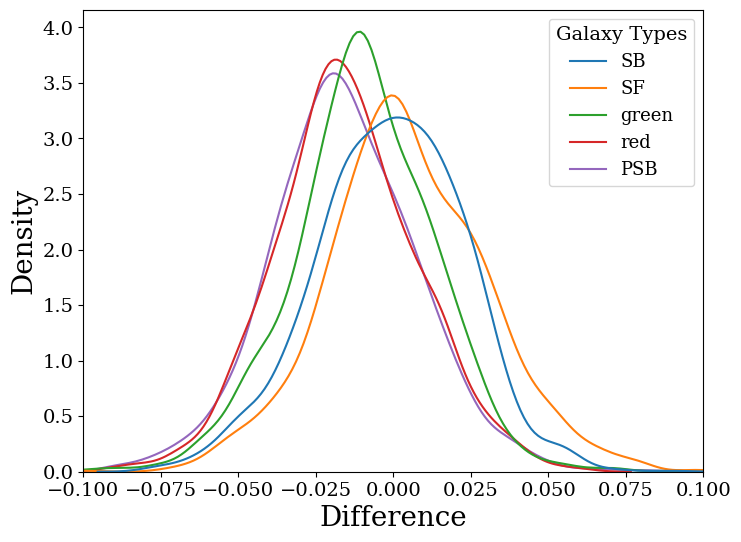

In [134]:
fig, ax = plt.subplots(figsize=(8,6))
graphGalTypeHist(trainGraphData_initial[2], trainGraphData_initial[3], ax,le)

with logits ^


wihout logits_

In [76]:
hiddenlayerCh=[30,43,25,77,39]
fcLayerCh=1004
kernal=[99,9,11,5,3]
stride=[1,1,1,2,3]
alexNetModel=AlexNet_noLogits(hiddenlayerCh,fcLayerCh, kernal, stride)

loss= nn.MSELoss()
optimiser=torch.optim.Adam(alexNetModel.parameters(), lr=0.001, betas=(0.9, 0.999), weight_decay=0.0005)
lrScheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min')

# train
log_dir= 'drive/MyDrive/TensorBoard_Data/AlexNet-withLogits/fullDataRuns'
modelIndex=datetime.now().strftime("%Y%m%d-%H%M%S")
alexNetModel.to(device)
trainResNet_Regressor(alexNetModel, train_data_loader, valid_data_loader,optimiser, loss, 40, lrScheduler, log_dir,modelIndex,True, None)


  0%|          | 0/40 [00:00<?, ?it/s]

Epoch No: 1 Train loss:  1.1610411289317364 Valid loss: tensor(0.0077, device='cuda:0') lr 0.001
Epoch No: 11 Train loss:  0.007086311058479954 Valid loss: tensor(0.0038, device='cuda:0') lr 0.001
Epoch No: 21 Train loss:  0.005133047093510289 Valid loss: tensor(0.0028, device='cuda:0') lr 0.001
Epoch No: 31 Train loss:  0.0036528721398843282 Valid loss: tensor(0.0019, device='cuda:0') lr 0.001
Epoch No: 40 Train loss:  0.002476850028721277 Valid loss: tensor(0.0028, device='cuda:0') lr 0.001
Best Epoch: 39


[0.002476850028721277, tensor(0.0028, device='cuda:0')]

In [79]:
#graph data

# without gal type logits
hiddenlayerCh=[30,43,25,77,39]
fcLayerCh=1004
kernal=[99,9,11,5,3]
stride=[1,1,1,2,3]


name='ANV2- 0309-192121'

modelDict = torch.load('/content/drive/MyDrive/TensorBoard_Data/AlexNet-withLogits/fullDataRuns/best_model/20250309-192121.pt', map_location=torch.device(device))
AN_Model=AlexNet_noLogits( hiddenlayerCh,fcLayerCh, kernal, stride)
AN_Model.load_state_dict(modelDict)
AN_Model.to(device)

trainGraphData_initial, valGraphData_initial=dataFor_graphPredictionTruth(AN_Model, train_data_loader, valid_data_loader)

<ipython-input-79-66555357032b>:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  modelDict = torch.load('/content/drive/MyDrive/TensorBoard_Data/AlexNet-withLogits/fullData

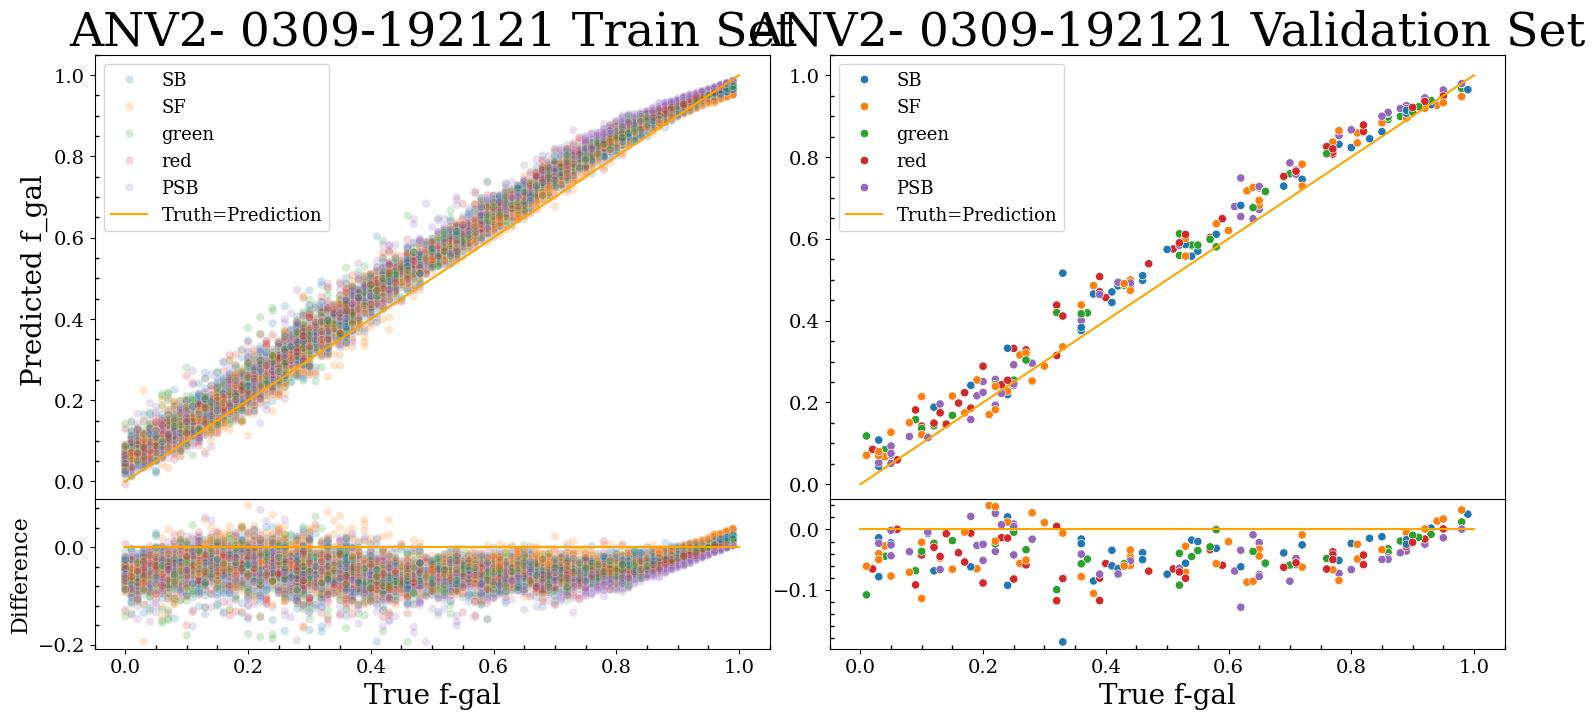

In [80]:
#graph the results
%matplotlib inline
fig, ax=plt.subplots(figsize=(15,6), ncols=2)
graphPredictionTruth(*trainGraphData_initial,*valGraphData_initial,name, ax, True,le)

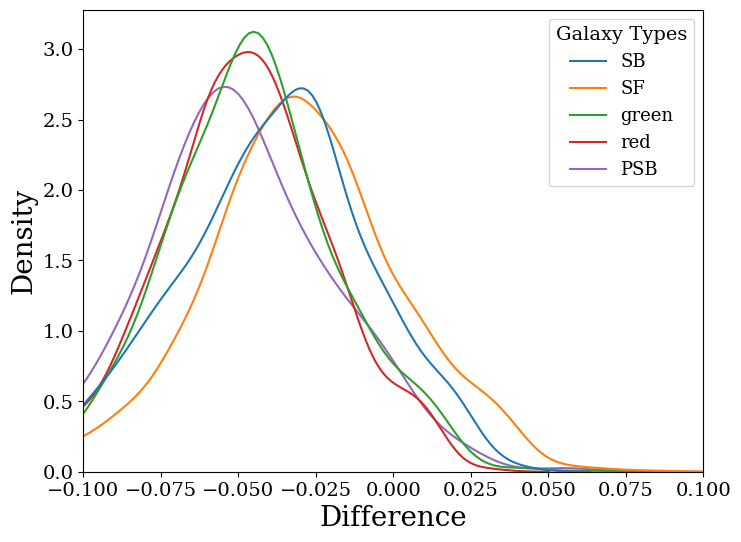

In [81]:
fig, ax = plt.subplots(figsize=(8,6))
graphGalTypeHist(trainGraphData_initial[2], trainGraphData_initial[3], ax,le)